In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = np.sqrt(512 * 1e-42) # strain
sigma_inj         = sigma/10.
NSegments         = 50
Fs                = 1024. # Hz
segmentDuration   = 64.0 # s
t0                = 0 # s
TAvg              = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFStoch=1/TAvg
NAvgs = 2 * int(segmentDuration / TAvg) - 1
jobDuration = NSegments * segmentDuration

In [3]:
# Theoretical PSD and sigma for white GWB and white noise

Nfreqs = int((Fs/2) / deltaFStoch)
alpha=3 # white signal
fref=25

w1w2bar, w1w2squaredbar,_,_ = window_factors(NSamplesPerSegment)
PSD_theor = 2*(sigma**2)*deltaT
Pgw_theor = 2*(sigma_inj**2)*deltaT

H_theor = (3*H0**2)/(10*np.pi**2*fref**3) # don't need *(P1.freqs/fref)**(alpha-3) for alpha=3
Y_theor = Pgw_theor/H_theor

var_theor = 1./((segmentDuration)*2*Nfreqs*deltaFStoch * H_theor**2/(PSD_theor**2))
var_theor = w1w2squaredbar / w1w2bar**2 * var_theor
sigma_theor = np.sqrt(var_theor)

print('sigma_theor =', sigma_theor)
print('Y_theor =', Y_theor)

sigma_theor = 0.0002666003559166893
Y_theor = 0.0004894401662160896


In [4]:
# simulate the time series data
noise1=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
noise2=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
inj=sigma_inj*np.random.randn(int(NSamplesPerSegment*NSegments))

times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

d1=TimeSeries(times,noise1 + inj)
d2=TimeSeries(times,noise2 + inj)

In [5]:
# run stochastic pipeline
alpha=3
fref=25
Ys, sigs, Y_fs, var_fs, Y0_fs, var0_fs, segmentStartTimes, freqs=stochastic(d1,d2,segmentDuration,deltaFStoch,
                                                                            fref=fref,alpha=alpha)

stochastic: Done with Interval 1 / 95
	Y       = 1.026007e-03
	sigma   = 2.655024e-04
	SNR     = 3.864396
stochastic: Done with Interval 2 / 95
	Y       = 1.618345e-04
	sigma   = 2.638132e-04
	SNR     = 0.613443
stochastic: Done with Interval 3 / 95
	Y       = 1.234922e-04
	sigma   = 2.633698e-04
	SNR     = 0.468893
stochastic: Done with Interval 4 / 95
	Y       = 2.635589e-04
	sigma   = 2.646245e-04
	SNR     = 0.995973
stochastic: Done with Interval 5 / 95
	Y       = 7.342972e-04
	sigma   = 2.648635e-04
	SNR     = 2.772361


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/2601316946.py:109: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3))
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/2601316946.py:110: RuntimeWarning: invalid value encountered in multiply
  S_alpha = FrequencySeries(freqs, S0.data * (freqs/fref)**alpha )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/2601316946.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  Y0_fs[:,II],var0_fs[:,II] = Y0_f.data, var0_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/2601316946.py:131: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/2601316946.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II], sigs[

stochastic: Done with Interval 6 / 95
	Y       = 6.266647e-04
	sigma   = 2.638725e-04
	SNR     = 2.374877
stochastic: Done with Interval 7 / 95
	Y       = 7.932773e-04
	sigma   = 2.646443e-04
	SNR     = 2.997523
stochastic: Done with Interval 8 / 95
	Y       = 7.878471e-04
	sigma   = 2.648419e-04
	SNR     = 2.974782
stochastic: Done with Interval 9 / 95
	Y       = 3.913874e-04
	sigma   = 2.640063e-04
	SNR     = 1.482492
stochastic: Done with Interval 10 / 95
	Y       = 9.077055e-04
	sigma   = 2.644069e-04
	SNR     = 3.432987
stochastic: Done with Interval 11 / 95
	Y       = 4.600020e-04
	sigma   = 2.655590e-04
	SNR     = 1.732203
stochastic: Done with Interval 12 / 95
	Y       = 2.771600e-04
	sigma   = 2.648932e-04
	SNR     = 1.046308
stochastic: Done with Interval 13 / 95
	Y       = 3.816975e-04
	sigma   = 2.644163e-04
	SNR     = 1.443548
stochastic: Done with Interval 14 / 95
	Y       = 6.895542e-04
	sigma   = 2.643328e-04
	SNR     = 2.608659
stochastic: Done with Interval 15 / 95
	Y

In [6]:
# combine point estimates and error bars assuming that stochastic was run with fixed alpha
Y_opt, sig_opt = postprocessing(Ys,sigs,jobDuration,segmentDuration,deltaFStoch,deltaT,bufferSecs=0)

print('Y_opt =', Y_opt)
print('sig_opt =', sig_opt)

Y_opt = 0.00048286947295260696
sig_opt = 2.8770627827873342e-05


In [7]:
# ALTERNATIVE CALCULATION!!!
# first combine spectra over segments

Y0_f,var0_f=postprocessing_spectra(Y0_fs,var0_fs,Ys, sigs,jobDuration,segmentDuration,deltaFStoch,deltaT)

# then combine over freqs, weighting as appropriate
f_filter=freqs>0.
Y_opt_alt,sig_opt_alt=calc_Y_sigma_from_Yf_varf(Y0_f[f_filter], var0_f[f_filter],freqs=freqs[f_filter],alpha=3,fref=25)

print('Y_opt_alt =', Y_opt_alt)
print('sig_opt_alt =', sig_opt_alt)

Y_opt_alt = 0.0004828617674160415
sig_opt_alt = 2.877057689527459e-05


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:28: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:29: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:33: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:34: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:43: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215

In [8]:
# ALTERNATIVE CALCULATION!!!
# first combine spectra over segments

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,Ys, sigs,jobDuration,segmentDuration,deltaFStoch,deltaT)

# then combine over freqs, weighting as appropriate
f_filter=freqs>0.
Y_opt_alt,sig_opt_alt=calc_Y_sigma_from_Yf_varf(Y_f[f_filter],var_f[f_filter],freqs=None)

print('Y_opt_alt =', Y_opt_alt)
print('sig_opt_alt =', sig_opt_alt)

Y_opt_alt = 0.00048286947295260706
sig_opt_alt = 2.877062782787335e-05


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:28: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:29: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:33: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:34: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215879.py:43: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_66919/1591215

18:31 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
18:31 bilby INFO    : Analysis priors:
18:31 bilby INFO    : A=Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
18:31 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
18:31 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
18:31 bilby INFO    : Analysis likelihood noise evidence: -1860.1220230725348
18:31 bilby INFO    : Single likelihood evaluation took 1.115e-04 s
18:31 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None,

4520it [00:05, 684.80it/s, bound:99 nc: 24 ncall:7.8e+04 eff:5.8% logz-ratio=134.64+/-nan dlogz:0.108>0.1]       

18:31 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


4558it [00:06, 671.58it/s, bound:101 nc:  1 ncall:8.0e+04 eff:6.4% logz-ratio=134.74+/-0.11 dlogz:0.000>0.1]

18:31 bilby INFO    : Rejection sampling nested samples to obtain 1374 posterior samples
18:31 bilby INFO    : Sampling time: 0:00:06.785414
18:31 bilby INFO    : Summary of results:
nsamples: 1374
ln_noise_evidence: -1860.122
ln_evidence: -1725.382 +/-  0.135
ln_bayes_factor: 134.740 +/-  0.135



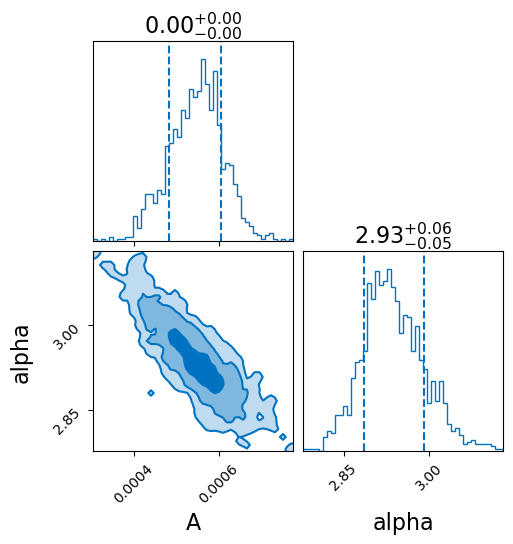

In [9]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-10,1e-3,-5,5
fref=25

likelihood = BasicPowerLawGWBLikelihood(Y0_f[1:],var0_f[1:],freqs[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=50000)
result.plot_corner()

In [10]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

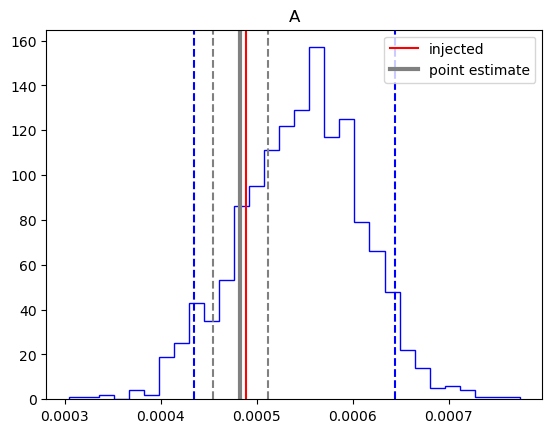

In [11]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(Y_theor,color='red', label='injected')

plt.axvline(Y_opt,color='grey', linewidth=3, label='point estimate')
plt.axvline(Y_opt+sig_opt,color='grey', linestyle='--')
plt.axvline(Y_opt-sig_opt,color='grey', linestyle='--')

plt.legend()

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

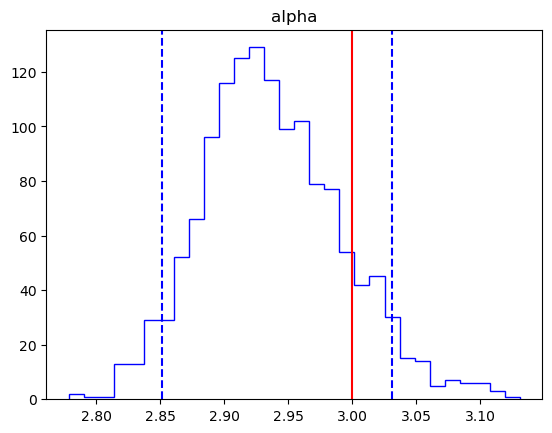

In [12]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(3,color='red')

plt.title('alpha')
plt.xlabel('')